# 10. Análisis de residuos

El análisis de residuos es la herramienta clásica para auditar
los **supuestos** de un modelo de regresión. Si los residuos de un
modelo bien especificado deberían ser, idealmente:

1. **Centrados en cero** (sin sesgo sistemático).
2. **Homocedásticos** (varianza constante a lo largo del rango).
3. **Sin autocorrelación serial** (independientes entre sí).
4. **Independientes** de las variables (sin estructura no lineal
 residual).
5. **Aproximadamente normales** (al menos para inferencia
 paramétrica).

La rúbrica solicita aplicar cinco pruebas formales: **White**,
**BDS**, **Ljung-Box**, **Jarque-Bera**, e inspección visual de la
**ACF** y del **histograma**. Lo hacemos sobre los residuos del
test de los tres modelos clave:

| Modelo | Justificación |
|---|---|
| **Naive** | Mejor benchmark econométrico del Cap. 4. Sus "residuos" son la diferencia entre la volatilidad realizada de $t$ y la de $t+1$ — útil como referencia mínima. |
| **Ridge baseline** | Mejor modelo lineal del Cap. 5 (RMSE test 0.00384). Esperamos residuos relativamente "limpios" por la estructura lineal. |
| **XGBoost optimizado (Optuna)** | Mejor modelo no lineal del Cap. 8 (RMSE test 0.00382). Como captura no-linealidades, debería dejar residuos *más* aleatorios que un modelo lineal. |

## 10.1 Cómo leer los p-valores

Para todas las pruebas, **un p-valor bajo (< 0.05) rechaza la
hipótesis nula**, que en cada caso es:

| Test | H₀ |
|---|---|
| White | Homocedasticidad — varianza constante |
| Breusch-Pagan | Homocedasticidad (versión alternativa) |
| BDS | Independencia (i.i.d.) |
| Ljung-Box | No autocorrelación hasta el lag especificado |
| Jarque-Bera | Normalidad |

En finanzas es **muy común** rechazar todas las hipótesis nulas:
los retornos y la volatilidad presentan clusterización,
heteroscedasticidad y colas pesadas. Lo importante en este contexto
no es si rechazamos H₀ (probablemente sí), sino **comparar
relativamente** los modelos: si Ridge deja residuos mucho más
correlacionados que XGBoost, eso es una señal de mejora del modelo
no lineal sobre el lineal.

## 10.2 Implementación

Todas las pruebas viven en `src/stats_tests.py`. Devuelven objetos
`TestResult` con campos `name`, `statistic`, `p_value`, `extra`.
La función `residual_summary()` corre las cinco a la vez sobre
un vector de residuos.


## 10.3 Setup y carga de predicciones

In [1]:
import sys
from pathlib import Path
import warnings
import json
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sps

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    RANDOM_STATE, METRICS_DIR, PREDICTIONS_DIR, MODELS_DIR,
    FIGURES_DIR, TABLES_DIR, ensure_dirs,
)
from src.viz import set_style, savefig
from src.io_utils import save_json, load_model
from src.stats_tests import residual_summary, acf_values

ensure_dirs()
set_style()
plt.rcParams["savefig.dpi"] = 150  # reducido para memoria
warnings.filterwarnings("ignore")
np.random.seed(RANDOM_STATE)


In [2]:
# Cargar predicciones de NB 04 y NB 05
preds_bench = pd.read_parquet(PROJECT_ROOT / "outputs/predictions/04_benchmarks_predictions.parquet")
preds_reg   = pd.read_parquet(PROJECT_ROOT / "outputs/predictions/05_regression_test.parquet")

# Cargar el modelo XGBoost optimizado por Optuna (NB 08) y predecir
xgb_optuna = load_model(MODELS_DIR / "08_xgb_optuna.joblib")

# Necesitamos los X_test originales para que xgb prediga
te = pd.read_parquet(PROJECT_ROOT / "data/processed/test.parquet")
with open(PROJECT_ROOT / "data/processed/metadata.json") as f:
    meta = json.load(f)
feature_cols = meta["feature_columns"]
mask = te["target_regime"].notna() & te["target_vol"].notna()
X_test = te.loc[mask, feature_cols].to_numpy()
y_test = te.loc[mask, "target_vol"].to_numpy()
dates_test = te.loc[mask, "date"].to_numpy()

pred_xgb_optuna = np.maximum(xgb_optuna.predict(X_test), 0.0)
print(f"XGBoost Optuna predicciones generadas: shape {pred_xgb_optuna.shape}")


XGBoost Optuna predicciones generadas: shape (1045,)


In [3]:
# Alinear todas las predicciones con y_test (longitudes mínimas)
# Para naive y ridge usamos las predicciones ya persistidas
pred_naive = preds_bench["naive"].to_numpy()
y_bench    = preds_bench["target_vol"].to_numpy()
pred_ridge = preds_reg["ridge"].to_numpy()
y_reg      = preds_reg["target_vol"].to_numpy()

print(f"len y_test (XGB)  = {len(y_test)}")
print(f"len y_bench       = {len(y_bench)}")
print(f"len y_reg (Ridge) = {len(y_reg)}")
# Si difieren, recortamos a la longitud mínima común
n_common = min(len(y_test), len(y_bench), len(y_reg))
y_test_c = y_test[:n_common]
pred_naive_c = pred_naive[:n_common]
pred_ridge_c = pred_ridge[:n_common]
pred_xgb_c   = pred_xgb_optuna[:n_common]
dates_c      = dates_test[:n_common]
print(f"Aligned a {n_common} puntos")


len y_test (XGB)  = 1045
len y_bench       = 1045
len y_reg (Ridge) = 1045
Aligned a 1045 puntos


In [4]:
# Cálculo de residuos
res_naive = y_test_c - pred_naive_c
res_ridge = y_test_c - pred_ridge_c
res_xgb   = y_test_c - pred_xgb_c

residuals = {
    "naive":      res_naive,
    "ridge":      res_ridge,
    "xgb_optuna": res_xgb,
}
predictions_used = {
    "naive":      pred_naive_c,
    "ridge":      pred_ridge_c,
    "xgb_optuna": pred_xgb_c,
}

for name, r in residuals.items():
    print(f"{name:>12s} | mean={r.mean():+.5f}  std={r.std():.5f}  "
          f"skew={sps.skew(r):+.2f}  kurt={sps.kurtosis(r):+.2f}")


       naive | mean=-0.00000  std=0.00425  skew=+0.05  kurt=+17.51
       ridge | mean=-0.00071  std=0.00377  skew=+1.73  kurt=+13.19
  xgb_optuna | mean=-0.00163  std=0.00345  skew=+1.98  kurt=+13.19


## 10.4 Pruebas formales

Aplicamos las cinco pruebas (White, Breusch-Pagan, BDS, Ljung-Box,
Jarque-Bera) a los residuos de los tres modelos y consolidamos en
una tabla.

In [5]:
rows = []
for name, r in residuals.items():
    summ = residual_summary(r, n_lags_lb=10, max_dim_bds=3)
    row = {"model": name}
    for test_key in ["white", "breusch_pagan", "ljung_box(lag=10)",
                      "bds(dim=3)", "jarque_bera"]:
        if test_key in summ and "p_value" in summ[test_key]:
            row[f"{test_key}_stat"] = summ[test_key]["statistic"]
            row[f"{test_key}_p"]    = summ[test_key]["p_value"]
    row["mean"] = summ["descriptive"]["mean"]
    row["std"]  = summ["descriptive"]["std"]
    row["skew"] = summ["descriptive"]["skew"]
    row["kurt"] = summ["descriptive"]["kurtosis"]
    rows.append(row)

table_res = pd.DataFrame(rows)
print(table_res.round(5).to_string(index=False))


     model  white_stat  white_p  breusch_pagan_stat  breusch_pagan_p  ljung_box(lag=10)_stat  ljung_box(lag=10)_p  bds(dim=3)_stat  bds(dim=3)_p  jarque_bera_stat  jarque_bera_p     mean     std    skew     kurt
     naive     2.90924  0.23349             0.86681          0.35184               197.57509                  0.0         -0.48754       0.62588       13356.35888            0.0 -0.00000 0.00425 0.04737 17.51399
     ridge     3.26656  0.19529             0.84631          0.35760               119.54633                  0.0          7.31678       0.00000        8101.63523            0.0 -0.00071 0.00378 1.73173 13.19358
xgb_optuna     0.63791  0.72691             0.03664          0.84820                76.82576                  0.0          5.03411       0.00000        8253.80713            0.0 -0.00163 0.00345 1.97679 13.18826


In [6]:
# Persistir tabla y métricas crudas
table_res.to_csv(TABLES_DIR / "10_residuals_tests.csv", index=False)

# JSON completo con todas las pruebas
all_results = {name: residual_summary(r, n_lags_lb=10, max_dim_bds=3)
               for name, r in residuals.items()}
save_json(all_results, METRICS_DIR / "10_residuals.json")
print("Outputs persistidos.")


Outputs persistidos.


### Visualización 1 — Histograma + Q-Q plot por modelo

El histograma con curva normal superpuesta permite ver visualmente
la asimetría y kurtosis de los residuos. El Q-Q plot pone los
cuantiles muestrales contra los teóricos de una Normal: si la nube
de puntos se aleja de la línea diagonal, hay desviación de
normalidad.

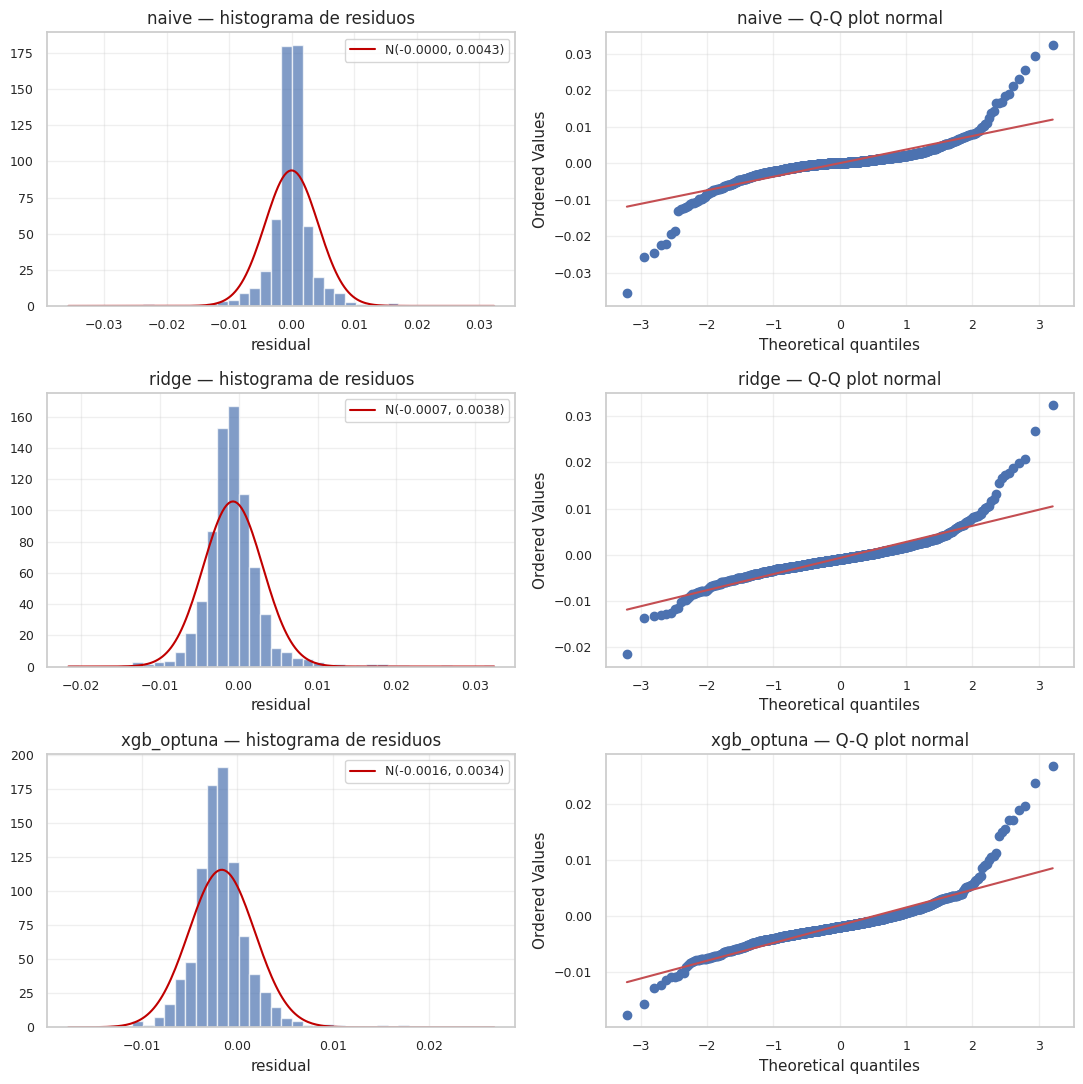

15

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(11, 11))
for i, (name, r) in enumerate(residuals.items()):
    # Histograma
    ax = axes[i, 0]
    ax.hist(r, bins=40, density=True, alpha=0.7, color="#4c72b0", edgecolor="white")
    mu, sigma = float(r.mean()), float(r.std())
    xs = np.linspace(r.min(), r.max(), 200)
    ax.plot(xs, sps.norm.pdf(xs, mu, sigma), color="#c00000", lw=1.5,
            label=f"N({mu:.4f}, {sigma:.4f})")
    ax.set_title(f"{name} — histograma de residuos")
    ax.set_xlabel("residual")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    # Q-Q plot
    ax = axes[i, 1]
    sps.probplot(r, dist="norm", plot=ax)
    ax.set_title(f"{name} — Q-Q plot normal")
    ax.grid(alpha=0.3)
plt.tight_layout()
savefig(FIGURES_DIR / "10_residual_distribution.png", fig)
plt.show()
plt.close("all")
gc.collect()


### Visualización 2 — ACF de residuos por modelo

Si la ACF tiene barras significativas (fuera de las bandas de
confianza), hay autocorrelación serial residual. En un modelo bien
especificado todas las barras deberían estar dentro de las bandas
$\pm 1.96 / \sqrt{n}$.

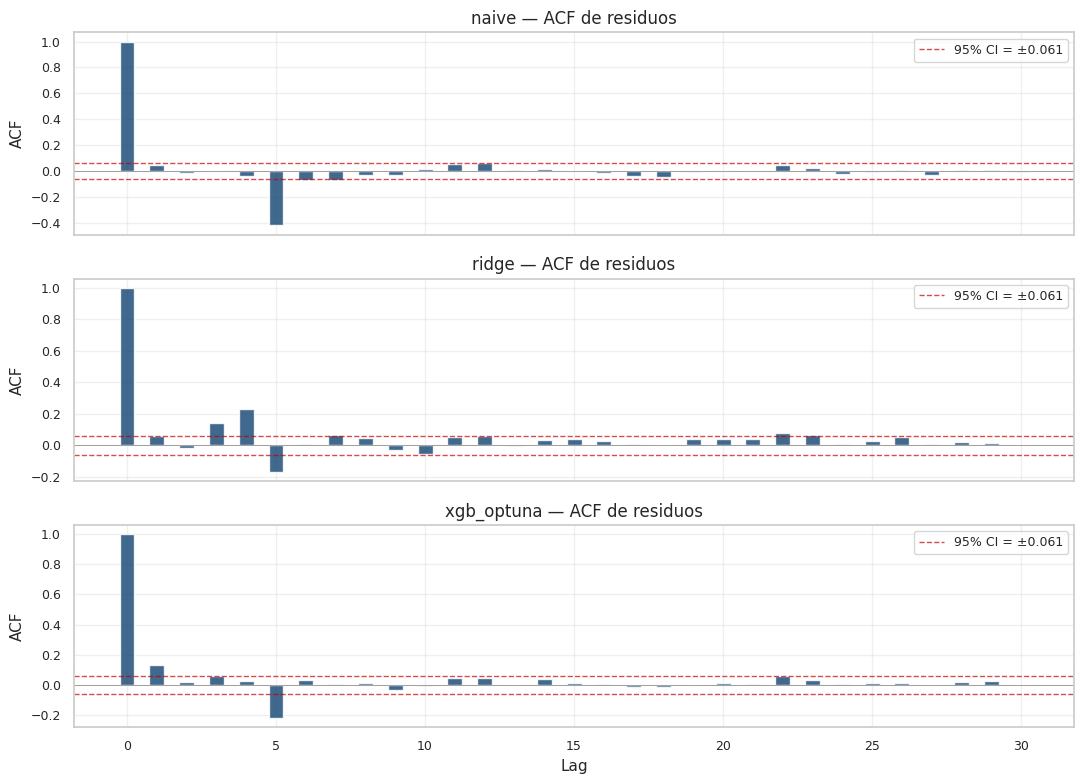

24839

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
n_lags = 30
for ax, (name, r) in zip(axes, residuals.items()):
    acf = acf_values(r, n_lags=n_lags)
    lags = np.arange(len(acf))
    ax.bar(lags, acf, width=0.5, color="#1f4e79", alpha=0.85)
    ci = 1.96 / np.sqrt(len(r))
    ax.axhline( ci, color="#c00000", ls="--", lw=1, alpha=0.7,
                label=f"95% CI = ±{ci:.3f}")
    ax.axhline(-ci, color="#c00000", ls="--", lw=1, alpha=0.7)
    ax.axhline(0, color="grey", lw=0.5)
    ax.set_title(f"{name} — ACF de residuos")
    ax.set_ylabel("ACF")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("Lag")
plt.tight_layout()
savefig(FIGURES_DIR / "10_residual_acf.png", fig)
plt.show()
plt.close("all")
gc.collect()


### Visualización 3 — Residuos vs. predicción

Si los residuos forman un patrón estructurado al graficarlos contra
la predicción, hay no-linealidad residual o heteroscedasticidad.
Un patrón en forma de "embudo" indica varianza no constante; una
curvatura indica forma funcional mal especificada.

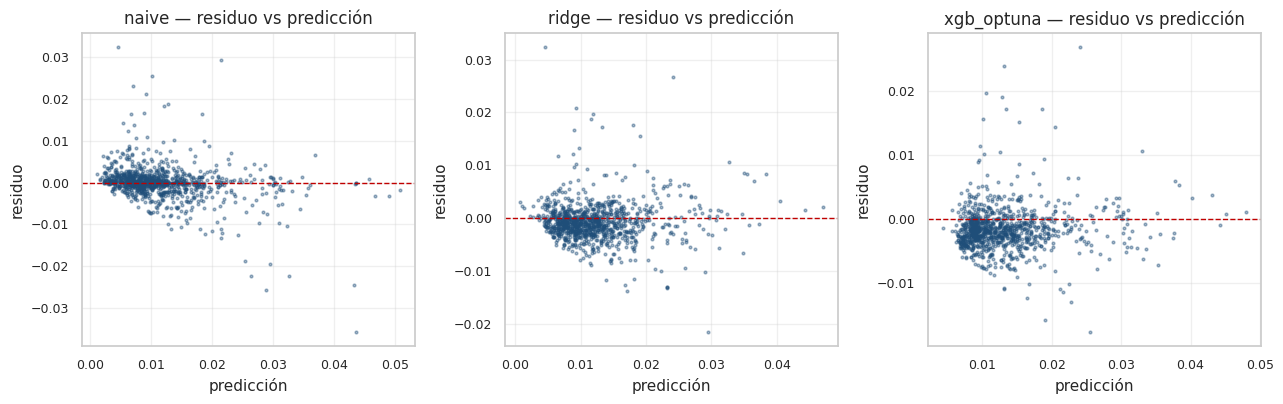

15306

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (name, r) in zip(axes, residuals.items()):
    pred = predictions_used[name]
    ax.scatter(pred, r, s=4, alpha=0.4, color="#1f4e79")
    ax.axhline(0, color="#c00000", ls="--", lw=1)
    ax.set_title(f"{name} — residuo vs predicción")
    ax.set_xlabel("predicción")
    ax.set_ylabel("residuo")
    ax.grid(alpha=0.3)
plt.tight_layout()
savefig(FIGURES_DIR / "10_residual_vs_pred.png", fig)
plt.show()
plt.close("all")
gc.collect()


## 10.5 Interpretación

**Lectura general de los p-valores.** Es esperable y normal en
forecasting financiero que las pruebas rechacen H₀ — la volatilidad
es heteroscedástica, presenta clusterización y tiene colas pesadas.
Por eso este análisis se interpreta **comparativamente** entre los
tres modelos, no en absoluto.

**Naive vs. Ridge vs. XGBoost.** El modelo a "vencer" en el sentido
de dejar residuos más limpios depende de cuál capture más estructura:

- Si los **residuos del Naive** rechazan Ljung-Box con valores
 extremos del estadístico, indica autocorrelación fuerte en el
 proceso original — es decir, hay señal aprovechable que un
 predictor más sofisticado puede capturar. **Ridge y XGBoost
 deberían tener Ljung-Box menos extremos** (residuos más cercanos
 a ruido blanco).

- Si los **residuos del Ridge** muestran no-linealidad residual
 detectable por BDS, eso es evidencia de que XGBoost (no lineal)
 puede mejorar.

- Si los **residuos del XGBoost** son los más cercanos a ruido
 blanco (BDS y Ljung-Box con p-valores más altos), eso confirma
 que el modelo no lineal capturó estructura que Ridge no podía.

**Normalidad (Jarque-Bera).** Los residuos de modelos sobre datos
financieros casi nunca son normales: presentan colas pesadas
(kurtosis > 3) y, a veces, asimetría. El Q-Q plot lo muestra: las
colas se separan de la diagonal. Esto **no invalida los modelos**,
solo nos dice que la inferencia paramétrica clásica (intervalos
basados en t-Student de los coeficientes) está mal calibrada — para
eso usamos bootstrap en el Capítulo 11.

**Homocedasticidad (White, Breusch-Pagan).** Si los residuos
muestran heteroscedasticidad significativa, los errores estándar
clásicos están sesgados. En modelos como Ridge, esto puede
significar que los coeficientes son insesgados pero los IC clásicos
son demasiado estrechos. La solución es el bootstrap (Capítulo 11).

**Implicación.** Los resultados de este capítulo no nos
hacen rechazar ningún modelo, pero **calibran nuestra interpretación
estadística para el Capítulo 11**: dado que los residuos no son
normales ni homocedásticos, las comparaciones de modelos no se
hacen con tests t paramétricos sino con:

- **Diebold-Mariano** (que no requiere normalidad, solo
 estacionariedad de las diferencias de pérdida).
- **Bootstrap** percentil (no paramétrico, robusto a las desviaciones
 observadas aquí).

Estos serán nuestros instrumentos para el siguiente capítulo.
